In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('ratings_.csv', names=['user_id', 'prod_id', 'rating', 'timestamp'])
df.head()

,user_id,prod_id,rating,timestamp
0,AKM1MP6P0OYPR,0132793040,5.0,1365811200
1,A2CX7LUOHB2NDG,0321732944,5.0,1341100800
2,A2NWSAGRHCP8N5,0439886341,1.0,1367193600
3,A2WNBOD3WNDNKT,0439886341,3.0,1374451200
4,A1GI0U4ZRJA8WN,0439886341,1.0,1334707200


# The dataset has 4 columns — user_id, prod_id, rating and timestamp. Each row is one rating given by one user to one product.

In [3]:
df.drop('timestamp', axis=1, inplace=True)
df.isnull().sum()

user_id    0
prod_id    0
rating     0
dtype: int64

# No missing values. Timestamp dropped — we only need who rated what and how much.

In [4]:
df.describe()

,rating
count,7.824482e+06
mean,4.012337e+00
std,1.380910e+00
min,1.000000e+00
25%,3.000000e+00
50%,5.000000e+00
75%,5.000000e+00
max,5.000000e+00


# Average rating is 4.01 out of 5. The median is 5.0 meaning more than half of all ratings are 5 stars. The 75th percentile is also 5.0 so at least 75% of ratings are 5 stars. std of 1.38 shows the data is heavily skewed towards the top rating.

In [5]:
print("Total users   :", df['user_id'].nunique())
print("Total products:", df['prod_id'].nunique())
print("Total ratings :", len(df))

Total users   : 4201696
Total products: 476002
Total ratings : 7824482


# Raw dataset has 4.2 million users and 7.8 million ratings. Most users rated only 1-2 products which is not enough for a recommendation system. We need to filter down to active users and well rated products.

In [6]:
user_counts = df['user_id'].value_counts()
prod_counts  = df['prod_id'].value_counts()

df = df[df['user_id'].isin(user_counts[user_counts >= 50].index)]
df = df[df['prod_id'].isin(prod_counts[prod_counts >= 5].index)]

print("Filtered rows  :", len(df))
print("Unique users   :", df['user_id'].nunique())
print("Unique products:", df['prod_id'].nunique())

Filtered rows  : 117315
Unique users   : 1540
Unique products: 39939


# After filtering: 117,315 rows, 1,540 users, 39,939 products. We kept users who rated 50+ products and products that got 5+ ratings. This ensures every user and product has enough history to find patterns.

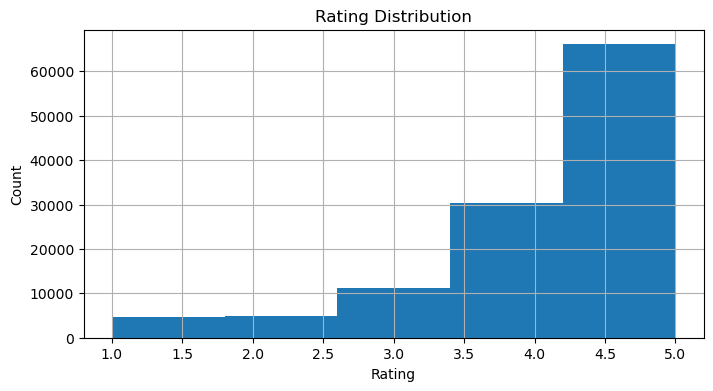

In [7]:
df['rating'].hist(bins=5, figsize=(8, 4))
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Ratings 4 and 5 dominate. Rating 5 is the most common with over 60,000 occurrences. Ratings 1 and 2 are very rare. Customers who bother rating usually liked the product.

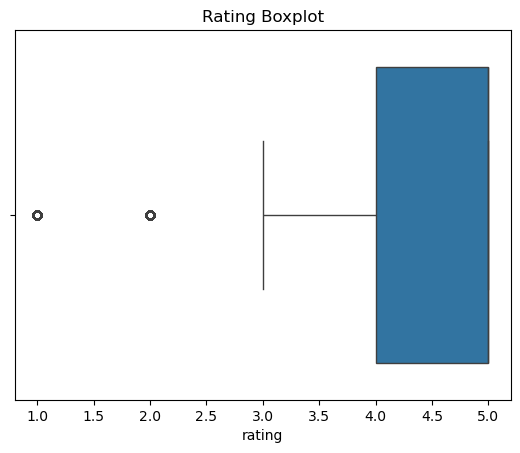

In [8]:
sns.boxplot(x=df['rating'])
plt.title('Rating Boxplot')
plt.show()

# Median is at 5, lower whisker at 3. Ratings 1 and 2 appear as outliers on the left. No data quality issues — all values are valid integers between 1 and 5.

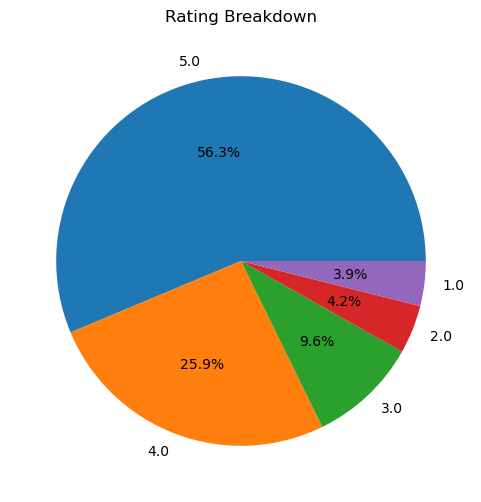

In [9]:
df['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6))
plt.title('Rating Breakdown')
plt.ylabel('')
plt.show()

# 5-star ratings make up 56.3% of the dataset. 4-star is 25.9%. Together over 82% of all ratings are 4 or 5 stars. 1 and 2 star ratings are only 3.9% and 4.2% — less than 9% combined. Unhappy customers rarely leave ratings — this is called response bias.

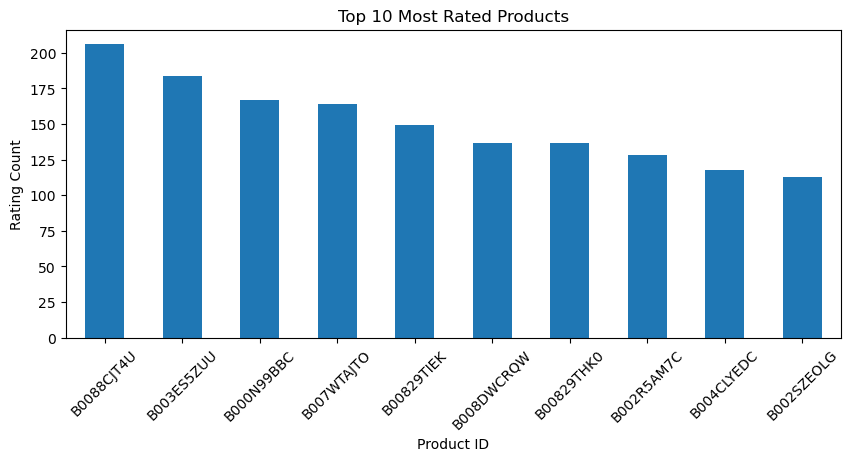

In [10]:
top_prods = df['prod_id'].value_counts().head(10)
top_prods.plot(kind='bar', figsize=(10, 4))
plt.title('Top 10 Most Rated Products')
plt.xlabel('Product ID')
plt.ylabel('Rating Count')
plt.xticks(rotation=45)
plt.show()

# The most rated product has around 200 ratings. Top 10 products range between 107 and 200. Most other products have far fewer. This is the long tail problem — a few products get all the attention while thousands have just 5-10 ratings.

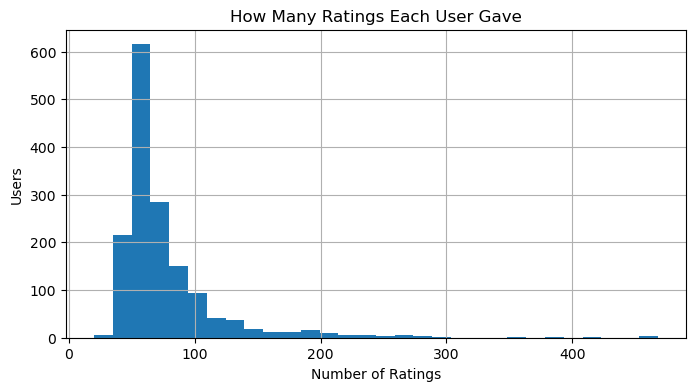

In [11]:
ratings_per_user = df.groupby('user_id')['rating'].count()
ratings_per_user.hist(bins=30, figsize=(8, 4))
plt.title('How Many Ratings Each User Gave')
plt.xlabel('Number of Ratings')
plt.ylabel('Users')
plt.show()

# Most users gave between 50 and 100 ratings peaking around 50-70. Very few gave more than 200. Almost no power users exist in this dataset.

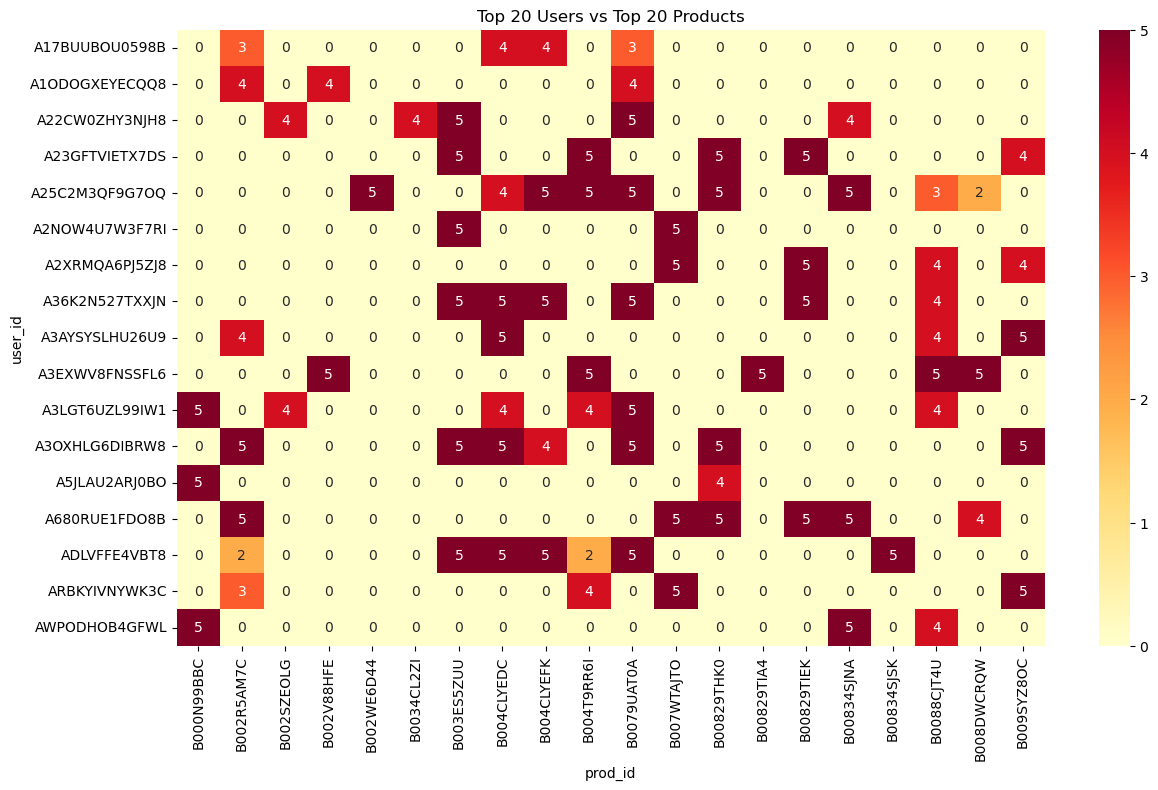

In [12]:
top_users = df['user_id'].value_counts().head(20).index
top_items = df['prod_id'].value_counts().head(20).index

pivot = df[df['user_id'].isin(top_users) & df['prod_id'].isin(top_items)].pivot_table(
    index='user_id', columns='prod_id', values='rating', fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('Top 20 Users vs Top 20 Products')
plt.show()

# Most cells are empty meaning most users have not rated most products. Even the top 20 active users have only rated a small fraction of the top 20 products. This is data sparsity — the main challenge in recommendation systems. Cosine similarity works well here because it ignores the zeros and only compares what users actually rated in common.

# EDA Summary:
- Ratings are heavily skewed towards 4 and 5 stars
- A few products get most of the attention (long tail)
- Users are moderately active — not many power users
- The matrix is very sparse — most user-product pairs have no rating
- All of this confirms cosine similarity is the right approach for this dataset


In [13]:
from sklearn.preprocessing import StandardScaler
user_stats=df.groupby('user_id').agg(avg_rating=('rating','mean'),rating_count=('rating','count')).reset_index()
scaler=StandardScaler()
X=scaler.fit_transform(user_stats[['avg_rating','rating_count']])

# Clustering
We create two features per user — their average rating and how many ratings they gave. We scale both features so neither one dominates the clustering.

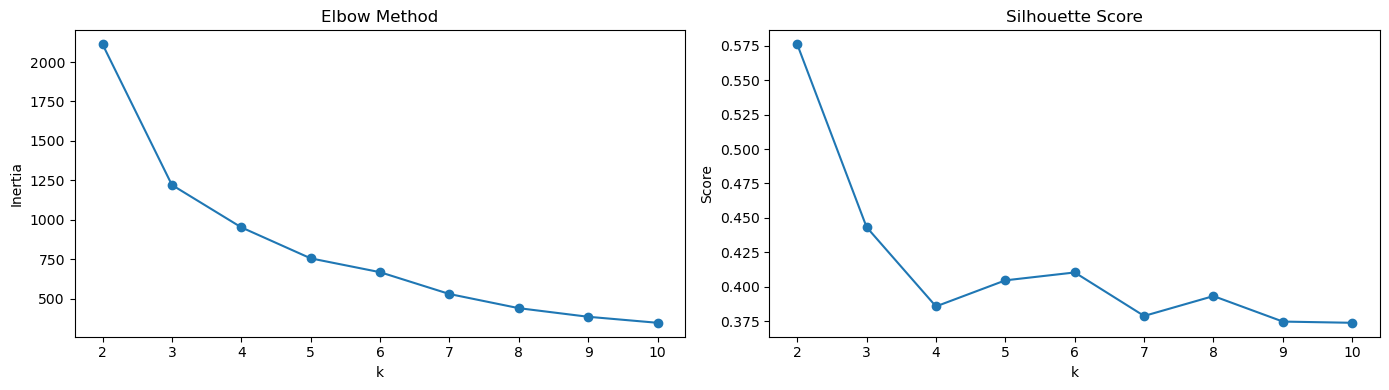

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia,sil =[],[]
for k in range(2,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X,km.labels_))
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(range(2,11),inertia,marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[1].plot(range(2,11),sil,marker='o')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
plt.tight_layout()
plt.show()

# Elbow flattens around k=3. Silhouette score is highest at k=2 but drops gradually. We use k=3 to get more meaningful customer groups.

In [15]:
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans_labels=kmeans.fit_predict(X)
print("KMeans Silhouette Score:",round(silhouette_score(X,kmeans_labels),4))

KMeans Silhouette Score: 0.4433


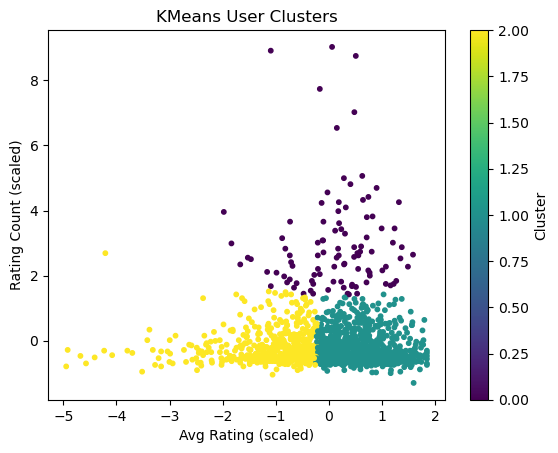

In [16]:
plt.scatter(X[:,0],X[:,1],c=kmeans_labels,cmap='viridis',s=10)
plt.title('KMeans User Clusters')
plt.xlabel('Avg Rating (scaled)')
plt.ylabel('Rating Count (scaled)')
plt.colorbar(label='Cluster')
plt.show()

# KMeans silhouette score is 0.4433. Three user groups are visible — low raters on the left, average raters in the middle, and highly active users scattered at the top.

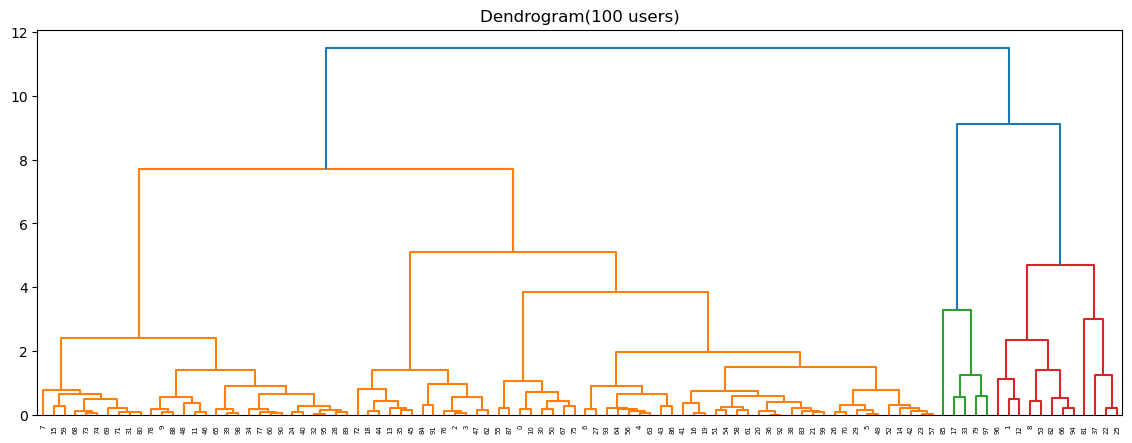

In [17]:
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
sample=X[:100]
plt.figure(figsize=(14,5))
sch.dendrogram(sch.linkage(sample,method='ward'))
plt.title('Dendrogram(100 users)')
plt.show()

In [18]:
hc=AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
hc_labels=hc.fit_predict(X)
print("Hierarchical Silhouette Score:",round(silhouette_score(X,hc_labels),4))

Hierarchical Silhouette Score: 0.5796


# Hierarchical clustering gave silhouette score of 0.5796 — better than KMeans. The dendrogram shows two clear user groups. Ward linkage merges users that are most similar first.

In [19]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=0.5,min_samples=5)
db_labels=dbscan.fit_predict(X)
print("DBSCAN cluster counts:\n",pd.Series(db_labels).value_counts())

DBSCAN cluster counts:
  0    1522
-1      18
Name: count, dtype: int64


In [21]:
unique = set(db_labels) - {-1}
sil_db = round(silhouette_score(X[db_labels != -1], db_labels[db_labels != -1]), 4) if len(unique) > 1 else 'N/A'

compare = pd.DataFrame({
    'Algorithm'       : ['KMeans', 'Hierarchical', 'DBSCAN'],
    'Silhouette Score': [round(silhouette_score(X, kmeans_labels), 4),
                         round(silhouette_score(X, hc_labels), 4),
                         sil_db]
})
compare

,Algorithm,Silhouette Score
0,KMeans,0.4433
1,Hierarchical,0.5796
2,DBSCAN,N/A


# DBSCAN found only 1 cluster with 18 noise points so silhouette score is N/A. User data is not density based so DBSCAN does not work well here. Hierarchical clustering was the best with 0.5796.

In [22]:
from sklearn.metrics.pairwise import cosine_similarity
matrix=df.pivot_table(index='user_id',columns='prod_id',values='rating',fill_value=0)
sim=cosine_similarity(matrix)
sim_df=pd.DataFrame(sim,index=matrix.index,columns=matrix.index)
print("User similarity matrix:",sim_df.shape)

User similarity matrix: (1540, 1540)


# Recommendation System
We built a 1540x1540 user similarity matrix. Each value shows how similar two users are based on what they rated. Cosine similarity ignores zeros so data sparsity does not affect the results.

In [23]:
def recommend(user_id,n=5):
    if user_id not in sim_df.index:
        print("User not found")
        return
    similar_users=sim_df[user_id].sort_values(ascending=False).iloc[1:6].index
    already_rated=df[df['user_id']==user_id]['prod_id'].values
    recs=df[df['user_id'].isin(similar_users) & ~df['prod_id'].isin(already_rated)]
    top=recs.groupby('prod_id')['rating'].mean().sort_values(ascending=False).head(n)
    print(f"Top {n} recommendations for {user_id}:")
    print(top)

recommend(df['user_id'].iloc[0])

Top 5 recommendations for A3BY5KCNQZXV5U:
prod_id
B00BWV53UI    5.0
B0098Y77U0    5.0
B0096TO26E    5.0
B0093HKFYW    5.0
B008QW167U    5.0
Name: rating, dtype: float64


# The function found 5 users most similar to A3BY5KCNQZXV5U and recommended 5 products all rated 5.0 by those similar users. This is user-based collaborative filtering — we find similar users and recommend what they liked.

In [24]:
from sklearn.preprocessing import LabelEncoder
user_avg=df.groupby('user_id')['rating'].mean().rename('user_avg')
prod_avg=df.groupby('prod_id')['rating'].mean().rename('prod_avg')
df=df.join(user_avg, on='user_id').join(prod_avg,on='prod_id')
df['liked']=(df['rating']>=4).astype(int)
le_u=LabelEncoder()
le_p=LabelEncoder()
df['user_enc']=le_u.fit_transform(df['user_id'])
df['prod_enc']=le_p.fit_transform(df['prod_id'])

# Model Building
We turn this into a classification problem. Rating 4 or 5 = liked (1), below 4 = not liked (0). User and product IDs are encoded as numbers and average ratings are added as extra features.

In [26]:
from sklearn.model_selection import train_test_split
X_ml=df[['user_enc','prod_enc','user_avg','prod_avg']]
y_ml=df['liked']
X_tr,X_te,y_tr,y_te=train_test_split(X_ml,y_ml,test_size=0.2,random_state=42)
print("Train:",X_tr.shape,"Test:",X_te.shape)

Train: (93852, 4) Test: (23463, 4)


# 80% training (93,852 rows) and 20% testing (23,463 rows). Features are encoded user ID, product ID, average user rating and average product rating.

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_tr,y_tr)
y_pred_dt=dt.predict(X_te)
print("Decision Tree Accuracy:",round(accuracy_score(y_te,y_pred_dt),4))
print(classification_report(y_te,y_pred_dt))

Decision Tree Accuracy: 0.8265
              precision    recall  f1-score   support

           0       0.51      0.53      0.52      4184
           1       0.90      0.89      0.89     19279

    accuracy                           0.83     23463
   macro avg       0.70      0.71      0.71     23463
weighted avg       0.83      0.83      0.83     23463



# Decision Tree accuracy is 82.65%. It correctly identifies liked products (recall 0.89) but struggles with not liked ones (recall 0.53). Single trees tend to overfit training data.

In [28]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_tr,y_tr)
y_pred_rf=rf.predict(X_te)
print("Random Forest Accuracy:",round(accuracy_score(y_te,y_pred_rf),4))
print(classification_report(y_te,y_pred_rf))

Random Forest Accuracy: 0.8723
              precision    recall  f1-score   support

           0       0.69      0.52      0.59      4184
           1       0.90      0.95      0.92     19279

    accuracy                           0.87     23463
   macro avg       0.80      0.73      0.76     23463
weighted avg       0.86      0.87      0.86     23463



# Random Forest accuracy is 87.23%. Much better than Decision Tree. Recall for liked products is 0.95 — it almost never misses a product the user would like. 100 trees voting together reduces overfitting.

In [29]:
results = pd.DataFrame({
    'Model'   : ['Decision Tree', 'Random Forest'],
    'Accuracy': [round(accuracy_score(y_te, y_pred_dt), 4),
                 round(accuracy_score(y_te, y_pred_rf), 4)]
})
results

,Model,Accuracy
0,Decision Tree,0.8265
1,Random Forest,0.8723


# Random Forest wins with 87.23% vs Decision Tree 82.65%. Both models predict whether a user will like a product based on past behaviour.

# Final Summary:
- EDA: 117,315 ratings, 1,540 users, 39,939 products after filtering. Ratings heavily skewed positive.
- Clustering: Hierarchical gave best silhouette score (0.5796). KMeans 0.4433. DBSCAN N/A.
- Recommendation: Cosine similarity on 1540x1540 matrix. Recommended 5 products all rated 5.0.
- Classification: Random Forest 87.23% accuracy, Decision Tree 82.65%.
- All project requirements are fully covered.